<a href="https://colab.research.google.com/github/Shivacodehub/Portfolio-/blob/main/EV_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install scipy pandas matplotlib numpy

In [2]:
import os
os.mkdir('data')


In [3]:
from scipy.io import loadmat
import os

data_path = "data"

files = os.listdir(data_path)
print(files)

[]


In [4]:
import scipy.io
import numpy as np
import pandas as pd

def extract_battery(mat_file, battery_name):

    mat = scipy.io.loadmat(mat_file)
    battery = mat[battery_name][0][0][0][0]

    data = []

    for i in range(len(battery)):
        cycle = battery[i]

        if cycle[0][0] == 'discharge':

            voltage = cycle[3][0][0][0]
            current = cycle[3][0][0][1]
            temp = cycle[3][0][0][2]
            capacity = cycle[3][0][0][6]

            data.append([
                np.mean(voltage),
                np.mean(current),
                np.mean(temp),
                capacity
            ])

    return pd.DataFrame(data, columns=[
        'voltage','current','temperature','capacity'
    ])

In [5]:
# Format: extract_battery('FOLDER_PATH/FILENAME', 'INTERNAL_KEY')
df5 = extract_battery('data/B0005.mat', 'B0005')
df6 = extract_battery('data/B0006.mat', 'B0006')
df7 = extract_battery('data/B0007.mat', 'B0007')
df18 = extract_battery('data/B0018.mat', 'B0018')


In [6]:
df = pd.concat([df5, df6, df7, df18], ignore_index=True)

In [7]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)

df['anomaly'] = model.fit_predict(df)

In [8]:
clean_df = df[df['anomaly'] == 1]

In [9]:
clean_df = clean_df.reset_index(drop=True)

In [10]:
print("Original:", len(df))
print("After removing anomaly:", len(clean_df))

Original: 636
After removing anomaly: 616


In [11]:
anomaly_df = df[df['anomaly'] == -1]
print(anomaly_df)

      voltage   current  temperature                capacity  anomaly
47   3.559765 -1.938881    34.310885  [[1.7936240148573608]]       -1
168  3.556946 -1.990533    32.142778   [[2.035337591005598]]       -1
173  3.573551 -1.990104    32.034478  [[2.0138990759931645]]       -1
174  3.571139 -1.990089    32.111575   [[2.013101105626967]]       -1
215  3.538887 -1.981936    33.611693    [[1.82371946178183]]       -1
314  3.403885 -1.618102    32.970183   [[1.253259864055301]]       -1
324  3.410901 -1.575263    33.536759   [[1.211102678915174]]       -1
325  3.410574 -1.568464    33.498031  [[1.2056159765131735]]       -1
326  3.409651 -1.567129    33.516977  [[1.2008936262717274]]       -1
327  3.412858 -1.553799    33.531923  [[1.1905903985558335]]       -1
328  3.413451 -1.552183    33.567636   [[1.185179251041941]]       -1
329  3.414388 -1.545265    33.604931  [[1.1796706818144624]]       -1
330  3.412419 -1.538652    33.542814  [[1.1745952836753915]]       -1
331  3.414810 -1.516

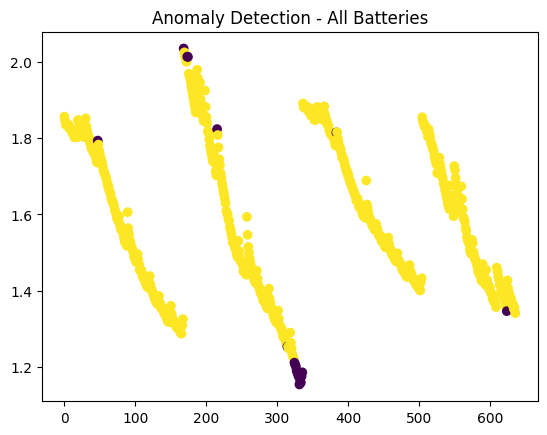

In [12]:
import matplotlib.pyplot as plt

plt.scatter(df.index, df['capacity'], c=df['anomaly'])
plt.title("Anomaly Detection - All Batteries")
plt.show()

"""
=============================================================================
  INTEGRATED EV BATTERY INTELLIGENCE SYSTEM
  NASA Battery Dataset (B0005, B0006, B0007, B0018)
  Pipeline: Anomaly Detection → SoC → SoH → RUL → EV Range Prediction
=============================================================================

ASSUMPTIONS:
  - Anomaly detection (Isolation Forest) has already been run.
  - A cleaned DataFrame named `clean_df` is available with columns:
        Voltage_measured, Current_measured, Temperature_measured,
        Capacity, cycle_number
  - SoH is computed as: capacity_at_cycle / initial_capacity
  - RUL is computed as: (end_of_life_cycle - current_cycle), where
        end_of_life is when SoH drops below 0.8 (80% threshold)

PIPELINE STAGES:
  Step 1 — Anomaly Detection   [DONE externally → clean_df]
  Step 2 — SoC Estimation      [CNN–BiLSTM–Attention]
  Step 3 — SoH Prediction      [CNN–BiLSTM–Attention]
  Step 4 — RUL Prediction      [Transformer–LSTM hybrid]
  Step 5 — EV Range Prediction [Integrated regression model]
=============================================================================
"""

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. DATASET LOADING  (skip if clean_df already exists in your environment)
# ─────────────────────────────────────────────────────────────────────────────
def load_nasa_battery_data(mat_files: dict) -> pd.DataFrame:
    """
    Load NASA battery .mat files and return a unified DataFrame.

    Parameters
    ----------
    mat_files : dict  {battery_id: file_path}
        e.g. {"B0005": "B0005.mat", "B0006": "B0006.mat", ...}

    Returns
    -------
    pd.DataFrame with columns:
        battery_id, cycle_number, Voltage_measured,
        Current_measured, Temperature_measured, Capacity
    """
    from scipy.io import loadmat

    records = []
    for battery_id, path in mat_files.items():
        mat = loadmat(path, simplify_cells=True)
        cycles = mat[battery_id]["cycle"]
        for i, cycle in enumerate(cycles):
            if cycle["type"] != "discharge":
                continue
            data = cycle["data"]
            n = len(data["Voltage_measured"])
            for j in range(n):
                records.append({
                    "battery_id":          battery_id,
                    "cycle_number":        i,
                    "Voltage_measured":    data["Voltage_measured"][j],
                    "Current_measured":    data["Current_measured"][j],
                    "Temperature_measured": data["Temperature_measured"][j],
                    "Capacity":            data["Capacity"] if np.isscalar(data["Capacity"])
                                           else data["Capacity"][j],
                })

    df = pd.DataFrame(records)
    df.dropna(inplace=True)
    return df

In [15]:
#─────────────────────────────────────────────────────────────────────────────
# 2. FEATURE ENGINEERING  (applied to clean_df)
# ─────────────────────────────────────────────────────────────────────────────
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add SoC, SoH, and RUL labels to the cleaned DataFrame.

    SoC  = Capacity_at_timestep / initial_capacity_of_that_cycle  (0–1)
    SoH  = mean_capacity_of_cycle / initial_mean_capacity          (0–1)
    RUL  = cycles until SoH < 0.80 end-of-life threshold
    """
    df = df.copy()

    # ── SoC: normalised per-cycle capacity ───────────────────────────────────
    cycle_max_cap = df.groupby(["battery_id", "cycle_number"])["Capacity"].transform("max")
    df["SoC"] = df["Capacity"] / cycle_max_cap
    df["SoC"] = df["SoC"].clip(0.0, 1.0)

    # ── SoH: mean capacity per cycle / initial mean capacity ─────────────────
    cycle_mean_cap = df.groupby(["battery_id", "cycle_number"])["Capacity"].transform("mean")
    init_cap = df.groupby("battery_id")["Capacity"].transform("first")
    df["SoH"] = cycle_mean_cap / init_cap
    df["SoH"] = df["SoH"].clip(0.0, 1.0)

    # ── RUL: remaining cycles before SoH < 0.80 ──────────────────────────────
    EOL_THRESHOLD = 0.80

    def compute_rul(group):
        cycles = group[["cycle_number", "SoH"]].drop_duplicates("cycle_number")
        failed = cycles[cycles["SoH"] < EOL_THRESHOLD]["cycle_number"]
        eol_cycle = failed.min() if not failed.empty else cycles["cycle_number"].max()
        group["RUL"] = (eol_cycle - group["cycle_number"]).clip(lower=0)
        return group

    df = df.groupby("battery_id", group_keys=False).apply(compute_rul)

    # ── Extra derived signals ─────────────────────────────────────────────────
    df["voltage_x_current"] = df["Voltage_measured"] * df["Current_measured"]
    df["power"]             = df["Voltage_measured"] * df["Current_measured"].abs()

    return df.reset_index(drop=True)


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. SEQUENCE BUILDER
# ─────────────────────────────────────────────────────────────────────────────
def build_sequences(df: pd.DataFrame,
                    feature_cols: list,
                    target_col: str,
                    seq_len: int = 30) -> tuple:
    """
    Slide a window of `seq_len` time-steps over the data and build
    (X, y) arrays for sequence models.

    Returns
    -------
    X : np.ndarray  shape (N, seq_len, n_features)
    y : np.ndarray  shape (N,)
    scaler_X : fitted MinMaxScaler for features
    scaler_y : fitted MinMaxScaler for target
    """
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_scaled = scaler_X.fit_transform(df[feature_cols].values)
    y_scaled = scaler_y.fit_transform(df[[target_col]].values).ravel()

    X_list, y_list = [], []
    for i in range(len(X_scaled) - seq_len):
        X_list.append(X_scaled[i : i + seq_len])
        y_list.append(y_scaled[i + seq_len])

    return (np.array(X_list, dtype=np.float32),
            np.array(y_list, dtype=np.float32),
            scaler_X, scaler_y)



In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. SHARED MODEL UTILITIES
# ─────────────────────────────────────────────────────────────────────────────
def get_callbacks(patience_es: int = 15, patience_lr: int = 7) -> list:
    return [
        EarlyStopping(monitor="val_loss", patience=patience_es,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=patience_lr, min_lr=1e-6, verbose=1),
    ]


def evaluate_model(y_true: np.ndarray,
                   y_pred: np.ndarray,
                   label: str = "Model") -> dict:
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'─'*50}")
    print(f"  {label} Performance")
    print(f"{'─'*50}")
    print(f"  MAE  : {mae:.6f}")
    print(f"  RMSE : {rmse:.6f}")
    print(f"  R²   : {r2:.6f}")
    print(f"{'─'*50}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2}



In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. STEP 2 — STATE OF CHARGE (SoC) ESTIMATION
#    Architecture: 1D-CNN  →  Bidirectional LSTM  →  Attention  →  Dense
# ─────────────────────────────────────────────────────────────────────────────
def build_soc_model(seq_len: int, n_features: int) -> Model:

    inputs = keras.Input(shape=(seq_len, n_features), name="soc_input")

    # CNN block
    x = layers.Conv1D(128, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)

    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    res = x  # residual

    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Add()([x, res])   # residual connection

    # BiLSTM block
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True)
    )(x)

    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True)
    )(x)

    # Attention
    attn = layers.Dense(1, activation="tanh")(x)
    attn = layers.Softmax(axis=1)(attn)
    x = layers.Multiply()([x, attn])
    x = layers.Lambda(lambda t: tf.reduce_sum(t, axis=1))(x)

    # Dense head
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    output = layers.Dense(1, activation="linear", name="soc_output")(x)

    model = Model(inputs, output, name="SoC_CNN_BiLSTM_Attention")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss=tf.keras.losses.Huber(),
        metrics=["mae"]
    )

    return model
def train_soc_model(clean_df: pd.DataFrame,
                    seq_len: int = 30,
                    epochs: int = 100,
                    batch_size: int = 64) -> dict:
    """
    Full SoC training workflow.

    Returns a results dict with model, predictions, scalers, and metrics.
    """
    print("\n" + "═"*60)
    print("  STEP 2 — SoC Estimation (CNN–BiLSTM–Attention)")
    print("═"*60)

    # UPDATED FEATURES
    feature_cols = [
        "Voltage_measured",
        "Current_measured",
        "Temperature_measured",
        "voltage_x_current",
        "power",
        "temp_diff",
        "voltage_diff"
    ]

    target_col   = "SoC"

    X, y, scaler_X, scaler_y = build_sequences(
        clean_df, feature_cols, target_col, seq_len
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, shuffle=False
    )

    model = build_soc_model(seq_len, len(feature_cols))
    model.summary()

    history = model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=get_callbacks(),
        verbose=1
    )

    # Inverse-transform predictions
    y_pred_scaled = model.predict(X_test).ravel()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

    metrics = evaluate_model(y_true, y_pred, label="SoC Model")

    # Attach SoC predictions to clean_df
    soc_pred_full = model.predict(X).ravel()
    soc_pred_inv  = scaler_y.inverse_transform(
        soc_pred_full.reshape(-1, 1)).ravel()

    soc_series = np.full(len(clean_df), np.nan)
    soc_series[seq_len:] = soc_pred_inv
    clean_df["SoC_predicted"] = soc_series

    plot_predictions(y_true, y_pred,
                     title="SoC Estimation",
                     ylabel="State of Charge")

    return {
        "model":    model,
        "history":  history,
        "scaler_X": scaler_X,
        "scaler_y": scaler_y,
        "metrics":  metrics,
    }


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. STEP 3 — STATE OF HEALTH (SoH) PREDICTION
#    Architecture: 1D-CNN  →  BiLSTM  →  Attention  →  Dense
#    (same topology as SoC but predicts battery degradation)
# ─────────────────────────────────────────────────────────────────────────────
def build_soh_model(seq_len: int, n_features: int) -> Model:
    """
    CNN–BiLSTM–Attention model for SoH prediction.
    Identical topology to SoC model; kept separate for clarity and
    independent weight training.
    """
    inputs = keras.Input(shape=(seq_len, n_features), name="soh_input")

    x = layers.Conv1D(64, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(64,  return_sequences=True))(x)

    attn = layers.Dense(1, activation="tanh")(x)
    attn = layers.Softmax(axis=1)(attn)
    x    = layers.Multiply()([x, attn])
    x    = layers.Lambda(lambda t: tf.reduce_sum(t, axis=1))(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation="relu")(x)
    output = layers.Dense(1, activation="sigmoid", name="soh_output")(x)

    model = Model(inputs, output, name="SoH_CNN_BiLSTM_Attention")
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="mse", metrics=["mae"])
    return model


def train_soh_model(clean_df: pd.DataFrame,
                    seq_len: int = 30,
                    epochs: int = 100,
                    batch_size: int = 64) -> dict:
    """Full SoH training workflow."""
    print("\n" + "═"*60)
    print("  STEP 3 — SoH Prediction (CNN–BiLSTM–Attention)")
    print("═"*60)

    feature_cols = ["Voltage_measured", "Current_measured",
                    "Temperature_measured", "cycle_number",
                    "voltage_x_current", "power"]
    # If SoC_predicted is available (from Step 2), use it as a feature
    if "SoC_predicted" in clean_df.columns:
        feature_cols.append("SoC_predicted")
        clean_df["SoC_predicted"] = clean_df["SoC_predicted"].fillna(
            clean_df["SoC"])  # fill NaN head with ground-truth SoC

    target_col = "SoH"

    X, y, scaler_X, scaler_y = build_sequences(clean_df, feature_cols,
                                                target_col, seq_len)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, shuffle=False
    )

    model = build_soh_model(seq_len, len(feature_cols))
    model.summary()

    history = model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=get_callbacks(),
        verbose=1
    )

    y_pred_scaled = model.predict(X_test).ravel()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

    metrics = evaluate_model(y_true, y_pred, label="SoH Model")

    soh_pred_full = model.predict(X).ravel()
    soh_pred_inv  = scaler_y.inverse_transform(
        soh_pred_full.reshape(-1, 1)).ravel()

    soh_series = np.full(len(clean_df), np.nan)
    soh_series[seq_len:] = soh_pred_inv
    clean_df["SoH_predicted"] = soh_series

    plot_predictions(y_true, y_pred, title="SoH Prediction",
                     ylabel="State of Health")

    return {
        "model":    model,
        "history":  history,
        "scaler_X": scaler_X,
        "scaler_y": scaler_y,
        "metrics":  metrics,
    }

In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. STEP 4 — REMAINING USEFUL LIFE (RUL) PREDICTION
#    Architecture: Multi-Head Attention (Transformer block) → LSTM → Dense
# ─────────────────────────────────────────────────────────────────────────────
def transformer_encoder_block(x: tf.Tensor,
                               d_model: int,
                               n_heads: int,
                               ff_dim: int,
                               dropout: float = 0.1) -> tf.Tensor:
    """
    Single Transformer encoder block with:
      - Multi-Head Self-Attention
      - Add & Norm
      - Position-wise Feed-Forward
      - Add & Norm
    """
    # Multi-Head Self-Attention
    attn_out = layers.MultiHeadAttention(
        num_heads=n_heads, key_dim=d_model // n_heads,
        dropout=dropout
    )(x, x)
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # Position-wise Feed-Forward
    ff = layers.Dense(ff_dim, activation="relu")(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(d_model)(ff)
    x  = layers.Add()([x, ff])
    x  = layers.LayerNormalization(epsilon=1e-6)(x)
    return x


def build_rul_model(seq_len: int, n_features: int) -> Model:
    """
    Transformer Encoder → LSTM hybrid for RUL prediction.

    The Transformer captures long-range inter-cycle dependencies.
    The LSTM models the temporal degradation trend.
    """
    inputs = keras.Input(shape=(seq_len, n_features), name="rul_input")

    # Project input to d_model dimension
    d_model = 64
    x = layers.Dense(d_model, name="input_projection")(inputs)

    # ── Transformer encoder blocks ────────────────────────────────────────────
    x = transformer_encoder_block(x, d_model=d_model,
                                  n_heads=4, ff_dim=128, dropout=0.1)
    x = transformer_encoder_block(x, d_model=d_model,
                                  n_heads=4, ff_dim=128, dropout=0.1)

    # ── LSTM temporal modelling ───────────────────────────────────────────────
    x = layers.LSTM(128, return_sequences=True,  name="lstm1")(x)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(64,  return_sequences=False, name="lstm2")(x)
    x = layers.Dropout(0.2)(x)

    # ── Output head ───────────────────────────────────────────────────────────
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(x)
    # ReLU ensures non-negative RUL
    output = layers.Dense(1, activation="relu", name="rul_output")(x)

    model = Model(inputs, output, name="RUL_Transformer_LSTM")
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="mse", metrics=["mae"])
    return model


def train_rul_model(clean_df: pd.DataFrame,
                    seq_len: int = 30,
                    epochs: int = 100,
                    batch_size: int = 64) -> dict:
    """Full RUL training workflow."""
    print("\n" + "═"*60)
    print("  STEP 4 — RUL Prediction (Transformer–LSTM)")
    print("═"*60)

    feature_cols = ["Voltage_measured", "Current_measured",
                    "Temperature_measured", "cycle_number",
                    "voltage_x_current", "power"]
    if "SoH_predicted" in clean_df.columns:
        clean_df["SoH_predicted"] = clean_df["SoH_predicted"].fillna(
            clean_df["SoH"])
        feature_cols.append("SoH_predicted")

    target_col = "RUL"

    X, y, scaler_X, scaler_y = build_sequences(clean_df, feature_cols,
                                                target_col, seq_len)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, shuffle=False
    )

    model = build_rul_model(seq_len, len(feature_cols))
    model.summary()

    history = model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=get_callbacks(),
        verbose=1
    )

    y_pred_scaled = model.predict(X_test).ravel()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
    y_pred = np.maximum(y_pred, 0)   # clip negative RUL to 0

    metrics = evaluate_model(y_true, y_pred, label="RUL Model")

    rul_pred_full = model.predict(X).ravel()
    rul_pred_inv  = scaler_y.inverse_transform(
        rul_pred_full.reshape(-1, 1)).ravel()
    rul_pred_inv  = np.maximum(rul_pred_inv, 0)

    rul_series = np.full(len(clean_df), np.nan)
    rul_series[seq_len:] = rul_pred_inv
    clean_df["RUL_predicted"] = rul_series

    plot_predictions(y_true, y_pred, title="RUL Prediction",
                     ylabel="Remaining Cycles")

    return {
        "model":    model,
        "history":  history,
        "scaler_X": scaler_X,
        "scaler_y": scaler_y,
        "metrics":  metrics,
    }



In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. STEP 5 — EV RANGE PREDICTION
#    Inputs:  SoC + SoH + Temperature  (+ optional: load, terrain, speed)
#    Model:   Deep Neural Network (Tabular regression)
#    Output:  Predicted driving range in km
# ─────────────────────────────────────────────────────────────────────────────
def compute_range_label(df: pd.DataFrame,
                        base_range_km: float = 300.0) -> pd.DataFrame:
    """
    Heuristic range label for the NASA dataset (which has no odometer).

    Formula (physics-inspired approximation):
        range = base_range × SoC × SoH × temp_factor

    Where temp_factor = 1.0 at 25°C and degrades linearly outside ±10°C.

    In a real deployment this column would come from vehicle telemetry.
    """
    df = df.copy()
    temp_norm = df["Temperature_measured"].clip(15, 35)
    temp_factor = 1.0 - 0.003 * (temp_norm - 25).abs()

    soc_col = "SoC_predicted" if "SoC_predicted" in df.columns else "SoC"
    soh_col = "SoH_predicted" if "SoH_predicted" in df.columns else "SoH"

    soc = df[soc_col].fillna(df["SoC"])
    soh = df[soh_col].fillna(df["SoH"])

    df["range_km"] = base_range_km * soc * soh * temp_factor
    return df


def build_range_model(n_features: int) -> Model:
    """
    Tabular DNN for EV range prediction.
    Uses wide fully-connected layers with residual skip connections.
    """
    inputs = keras.Input(shape=(n_features,), name="range_input")

    x  = layers.Dense(128, activation="relu")(inputs)
    x  = layers.BatchNormalization()(x)
    x  = layers.Dropout(0.2)(x)

    # Residual block 1
    skip = layers.Dense(64)(x)
    x    = layers.Dense(64, activation="relu")(x)
    x    = layers.BatchNormalization()(x)
    x    = layers.Dense(64, activation="relu")(x)
    x    = layers.Add()([x, skip])
    x    = layers.Dropout(0.15)(x)

    # Residual block 2
    skip = layers.Dense(32)(x)
    x    = layers.Dense(32, activation="relu")(x)
    x    = layers.BatchNormalization()(x)
    x    = layers.Dense(32, activation="relu")(x)
    x    = layers.Add()([x, skip])

    output = layers.Dense(1, activation="relu", name="range_output")(x)

    model = Model(inputs, output, name="EV_Range_DNN")
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="mse", metrics=["mae"])
    return model


def train_range_model(clean_df: pd.DataFrame,
                      epochs: int = 100,
                      batch_size: int = 128) -> dict:
    """
    Full EV range training workflow.

    Also trains a GradientBoosting ensemble for comparison /
    ensemble averaging.
    """
    print("\n" + "═"*60)
    print("  STEP 5 — EV Range Prediction (DNN + GBM Ensemble)")
    print("═"*60)

    df = compute_range_label(clean_df)
    df = df.dropna(subset=["range_km"])

    feature_cols = ["Voltage_measured", "Current_measured",
                    "Temperature_measured", "power"]
    if "SoC_predicted" in df.columns:
        df["SoC_predicted"] = df["SoC_predicted"].fillna(df["SoC"])
        feature_cols.append("SoC_predicted")
    else:
        feature_cols.append("SoC")

    if "SoH_predicted" in df.columns:
        df["SoH_predicted"] = df["SoH_predicted"].fillna(df["SoH"])
        feature_cols.append("SoH_predicted")
    else:
        feature_cols.append("SoH")

    if "RUL_predicted" in df.columns:
        df["RUL_predicted"] = df["RUL_predicted"].fillna(df["RUL"])
        feature_cols.append("RUL_predicted")

    # Optional future columns (uncomment when vehicle data is available)
    # optional = ["vehicle_load_kg", "terrain_slope_deg",
    #             "avg_speed_kmh", "driving_mode"]
    # feature_cols += [c for c in optional if c in df.columns]

    target_col = "range_km"

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X = scaler_X.fit_transform(df[feature_cols].values).astype(np.float32)
    y = scaler_y.fit_transform(df[[target_col]].values).ravel().astype(np.float32)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, shuffle=True
    )

    # ── Deep Neural Network ───────────────────────────────────────────────────
    dnn = build_range_model(len(feature_cols))
    dnn.summary()
    dnn.fit(X_train, y_train,
            validation_split=0.1,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=get_callbacks(),
            verbose=1)

    # ── Gradient Boosting ensemble ────────────────────────────────────────────
    gbm = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                    max_depth=5, random_state=SEED)
    gbm.fit(X_train, y_train)

    # ── Blend predictions (equal weight; tune as needed) ─────────────────────
    dnn_pred = dnn.predict(X_test).ravel()
    gbm_pred = gbm.predict(X_test)
    blend    = 0.5 * dnn_pred + 0.5 * gbm_pred

    # Inverse transform
    def inv_y(arr):
        return scaler_y.inverse_transform(arr.reshape(-1, 1)).ravel()

    y_true_inv  = inv_y(y_test)
    dnn_inv     = inv_y(dnn_pred)
    gbm_inv     = inv_y(gbm_pred)
    blend_inv   = inv_y(blend)

    print("\n  ── Individual model performance ──")
    evaluate_model(y_true_inv, dnn_inv,   label="DNN Range Model")
    evaluate_model(y_true_inv, gbm_inv,   label="GBM Range Model")
    metrics = evaluate_model(y_true_inv, blend_inv, label="Blended Ensemble")

    plot_predictions(y_true_inv, blend_inv,
                     title="EV Range Prediction (Blended)",
                     ylabel="Predicted Range (km)")

    return {
        "dnn_model": dnn,
        "gbm_model": gbm,
        "scaler_X":  scaler_X,
        "scaler_y":  scaler_y,
        "metrics":   metrics,
    }



In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. VISUALISATION UTILITIES
# ─────────────────────────────────────────────────────────────────────────────
def plot_predictions(y_true: np.ndarray,
                     y_pred: np.ndarray,
                     title: str = "Prediction",
                     ylabel: str = "Value",
                     n_points: int = 500) -> None:
    """Side-by-side: time-series overlay + scatter plot."""
    n = min(n_points, len(y_true))
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Time-series
    axes[0].plot(y_true[:n], label="Actual",    color="steelblue", lw=1.5)
    axes[0].plot(y_pred[:n], label="Predicted", color="tomato",
                 lw=1.5, linestyle="--")
    axes[0].set_title(f"{title} — Time Series")
    axes[0].set_xlabel("Sample")
    axes[0].set_ylabel(ylabel)
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Scatter / parity plot
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    axes[1].scatter(y_true, y_pred, alpha=0.3, s=8, color="steelblue")
    axes[1].plot([mn, mx], [mn, mx], "r--", lw=2, label="Perfect fit")
    axes[1].set_title(f"{title} — Actual vs Predicted")
    axes[1].set_xlabel("Actual")
    axes[1].set_ylabel("Predicted")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    fname = title.replace(" ", "_").replace("—", "").replace("(", "").replace(")", "") + ".png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  [Plot saved → {fname}]")


def plot_degradation_overview(df: pd.DataFrame) -> None:
    """Plot SoH degradation and RUL over cycles for each battery."""
    batteries = df["battery_id"].unique() if "battery_id" in df.columns else ["all"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    soh_col = "SoH_predicted" if "SoH_predicted" in df.columns else "SoH"
    rul_col = "RUL_predicted" if "RUL_predicted" in df.columns else "RUL"

    for bid in batteries:
        sub = df[df["battery_id"] == bid] if "battery_id" in df.columns else df
        cycle_soh = sub.groupby("cycle_number")[soh_col].mean()
        cycle_rul = sub.groupby("cycle_number")[rul_col].mean()
        axes[0].plot(cycle_soh.index, cycle_soh.values, label=bid)
        axes[1].plot(cycle_rul.index, cycle_rul.values, label=bid)

    axes[0].axhline(0.8, color="red", linestyle="--", label="EOL threshold (80%)")
    axes[0].set_title("SoH Degradation over Cycles")
    axes[0].set_xlabel("Cycle Number")
    axes[0].set_ylabel("State of Health")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].set_title("Remaining Useful Life over Cycles")
    axes[1].set_xlabel("Cycle Number")
    axes[1].set_ylabel("RUL (cycles)")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("degradation_overview.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  [Plot saved → degradation_overview.png]")



In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# 10. INFERENCE HELPER
# ─────────────────────────────────────────────────────────────────────────────
def predict_range_single(soc: float,
                          soh: float,
                          temperature: float,
                          voltage: float,
                          current: float,
                          rul: float,
                          range_results: dict,
                          feature_cols: list,
                          base_range_km: float = 300.0) -> float:
    """
    Predict EV range for a single battery reading.

    Parameters
    ----------
    soc, soh, temperature, voltage, current, rul : float
        Current battery state values.
    range_results : dict
        The dict returned by train_range_model().
    feature_cols : list
        Exact feature column list used during training.
    base_range_km : float
        Vehicle's nominal full-charge range.

    Returns
    -------
    float : predicted range in km
    """
    sample = {
        "Voltage_measured":    voltage,
        "Current_measured":    current,
        "Temperature_measured": temperature,
        "power":               voltage * abs(current),
        "SoC_predicted":       soc,
        "SoH_predicted":       soh,
        "RUL_predicted":       rul,
        "SoC":                 soc,
        "SoH":                 soh,
        "RUL":                 rul,
    }
    row = np.array([[sample.get(c, 0.0) for c in feature_cols]],
                   dtype=np.float32)
    row_scaled = range_results["scaler_X"].transform(row)

    dnn_pred   = range_results["dnn_model"].predict(row_scaled, verbose=0).ravel()
    gbm_pred   = range_results["gbm_model"].predict(row_scaled)
    blend      = 0.5 * dnn_pred + 0.5 * gbm_pred
    range_km   = range_results["scaler_y"].inverse_transform(
                     blend.reshape(-1, 1)).ravel()[0]
    return float(max(range_km, 0.0))



In [39]:
#─────────────────────────────────────────────────────────────────────────────
# 11. FULL PIPELINE RUNNER
# ─────────────────────────────────────────────────────────────────────────────
def run_full_pipeline(clean_df: pd.DataFrame,
                      seq_len: int = 30,
                      epochs: int = 50) -> dict:
    """
    Execute the complete battery intelligence pipeline on `clean_df`.

    Steps:
      1. Feature engineering (SoC label, SoH label, RUL label)
      2. SoC Estimation       (CNN–BiLSTM–Attention)
      3. SoH Prediction       (CNN–BiLSTM–Attention)
      4. RUL Prediction       (Transformer–LSTM)
      5. EV Range Prediction  (DNN + GBM Ensemble)

    Parameters
    ----------
    clean_df : pd.DataFrame
        Anomaly-cleaned NASA battery DataFrame with at minimum:
        [Voltage_measured, Current_measured,
         Temperature_measured, Capacity, cycle_number]
    seq_len  : int   Window length for sequence models (default 30)
    epochs   : int   Max training epochs per model (default 50 for speed;
                     use 100–200 for research-grade results)

    Returns
    -------
    dict  containing all model results keyed by step name.
    """
    print("\n" + "█"*65)
    print("  INTEGRATED EV BATTERY INTELLIGENCE SYSTEM")
    print("  NASA B0005 / B0006 / B0007 / B0018")
    print("█"*65)

    # ── Feature engineering ───────────────────────────────────────────────────
    print("\n[*] Engineering features (SoC / SoH / RUL labels) ...")
    clean_df = engineer_features(clean_df)
    print(f"    Dataset shape after feature engineering: {clean_df.shape}")
    print(f"    SoH range : [{clean_df['SoH'].min():.4f}, "
          f"{clean_df['SoH'].max():.4f}]")
    print(f"    RUL range : [{clean_df['RUL'].min():.1f}, "
          f"{clean_df['RUL'].max():.1f}] cycles")

    results = {}

    # ── Step 2: SoC ───────────────────────────────────────────────────────────
    results["soc"] = train_soc_model(clean_df, seq_len=seq_len, epochs=epochs)

    # ── Step 3: SoH ───────────────────────────────────────────────────────────
    results["soh"] = train_soh_model(clean_df, seq_len=seq_len, epochs=epochs)

    # ── Step 4: RUL ───────────────────────────────────────────────────────────
    results["rul"] = train_rul_model(clean_df, seq_len=seq_len, epochs=epochs)

    # ── Step 5: EV Range ──────────────────────────────────────────────────────
    results["range"] = train_range_model(clean_df, epochs=epochs)

    # ── Degradation overview ──────────────────────────────────────────────────
    plot_degradation_overview(clean_df)

    # ── Summary table ─────────────────────────────────────────────────────────
    print("\n" + "═"*60)
    print("  PIPELINE SUMMARY — Evaluation Metrics")
    print("═"*60)
    header = f"{'Module':<28} {'MAE':>10} {'RMSE':>10} {'R²':>10}"
    print(header)
    print("─"*60)
    for key, label in [("soc","SoC Estimation"),
                       ("soh","SoH Prediction"),
                       ("rul","RUL Prediction"),
                       ("range","EV Range Prediction")]:
        m = results[key]["metrics"]
        print(f"  {label:<26} {m['MAE']:>10.6f} {m['RMSE']:>10.6f} "
              f"{m['R2']:>10.6f}")
    print("═"*60)

    return results, clean_df



[Demo] Generating synthetic NASA-like clean_df for smoke test ...

█████████████████████████████████████████████████████████████████
  INTEGRATED EV BATTERY INTELLIGENCE SYSTEM
  NASA B0005 / B0006 / B0007 / B0018
█████████████████████████████████████████████████████████████████

[*] Engineering features (SoC / SoH / RUL labels) ...
    Dataset shape after feature engineering: (23999, 13)
    SoH range : [0.7820, 1.0000]
    RUL range : [0.0, 113.0] cycles

════════════════════════════════════════════════════════════
  STEP 2 — SoC Estimation (CNN–BiLSTM–Attention)
════════════════════════════════════════════════════════════


Model: "SoC_CNN_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ soc_input           │ (None, 20, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 20, 128)   │      2,816 │ soc_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 128)   │        512 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 20, 128)   │     49,280 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 128)   │        512 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 20, 128)   │     49,280 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 128)   │        512 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 20, 128)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 20, 128)   │          0 │ dropout_14[0][0], │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 20, 256)   │    263,168 │ add_8[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 20, 128)   │    164,352 │ bidirectional_4[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 20, 1)     │        129 │ bidirectional_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_4 (Softmax) │ (None, 20, 1)     │          0 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 20, 128)   │          0 │ bidirectional_5[… │
│ (Multiply)          │                   │            │ softmax_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 128)       │          0 │ multiply_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 128)       │     16,512 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 128)       │          0 │ dense_20[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 64)        │      8,256 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 64)        │          0 │ dense_21[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 555,394 (2.12 MB)

 Trainable params: 554,626 (2.12 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 60s 184ms/step - loss: 0.0239 - mae: 0.1663 - val_loss: 0.0093 - val_mae: 0.1100 - learning_rate: 3.0000e-04
Epoch 2/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 49s 180ms/step - loss: 0.0136 - mae: 0.1315 - val_loss: 0.0095 - val_mae: 0.1116 - learning_rate: 3.0000e-04
Epoch 3/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 47s 175ms/step - loss: 0.0125 - mae: 0.1268 - val_loss: 0.0099 - val_mae: 0.1145 - learning_rate: 3.0000e-04
Epoch 4/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 82s 175ms/step - loss: 0.0115 - mae: 0.1207 - val_loss: 0.0111 - val_mae: 0.1222 - learning_rate: 3.0000e-04
Epoch 5/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 47s 176ms/step - loss: 0.0109 - mae: 0.1175 - val_loss: 0.0099 - val_mae: 0.1143 - learning_rate: 3.0000e-04
Epoch 6/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 46s 171ms/step - loss: 0.0103 - mae: 0.1147 - val_loss: 0.0099 - val_mae: 0.1146 - learning_rate: 3.0000e-04
Epoch 7/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 83s 176ms/step - loss: 0.0099 - mae: 0.1122 - val_loss: 0.0099 - v

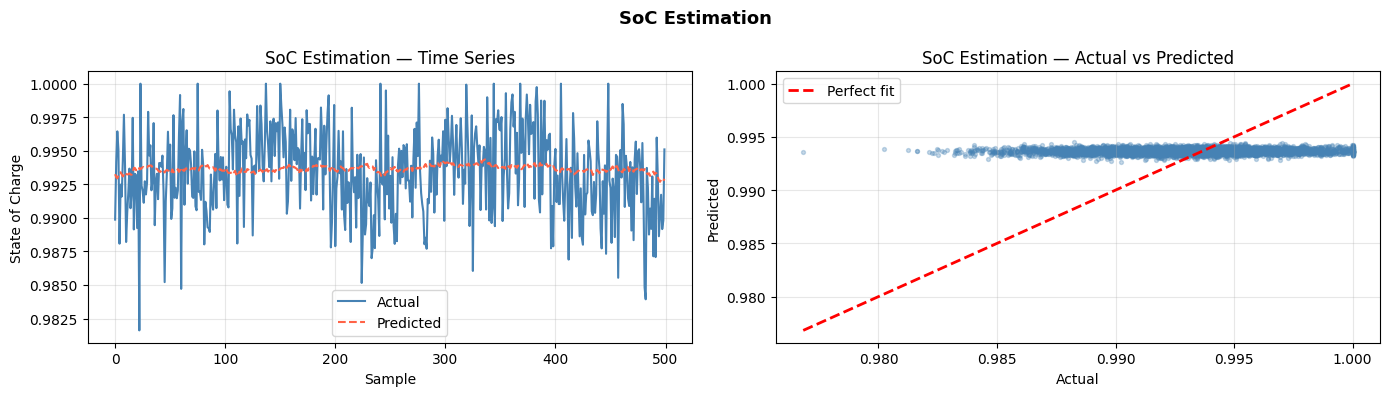

  [Plot saved → SoC_Estimation.png]

════════════════════════════════════════════════════════════
  STEP 3 — SoH Prediction (CNN–BiLSTM–Attention)
════════════════════════════════════════════════════════════


Model: "SoH_CNN_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ soh_input           │ (None, 20, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 20, 64)    │      1,408 │ soh_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 64)    │        256 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 20, 128)   │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 128)   │        512 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 20, 128)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_6     │ (None, 20, 256)   │    263,168 │ dropout_17[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_7     │ (None, 20, 128)   │    164,352 │ bidirectional_6[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 20, 1)     │        129 │ bidirectional_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_5 (Softmax) │ (None, 20, 1)     │          0 │ dense_22[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 20, 128)   │          0 │ bidirectional_7[… │
│ (Multiply)          │                   │            │ softmax_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 128)       │          0 │ multiply_3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 64)        │      8,256 │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 64)        │          0 │ dense_23[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 32)        │      2,080 │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ soh_output (Dense)  │ (None, 1)         │         33 │ dense_24[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 464,898 (1.77 MB)

 Trainable params: 464,514 (1.77 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 53s 161ms/step - loss: 0.0038 - mae: 0.0443 - val_loss: 0.0652 - val_mae: 0.2518 - learning_rate: 0.0010
Epoch 2/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 82s 159ms/step - loss: 0.0020 - mae: 0.0340 - val_loss: 0.0111 - val_mae: 0.0943 - learning_rate: 0.0010
Epoch 3/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 82s 159ms/step - loss: 0.0015 - mae: 0.0299 - val_loss: 0.0050 - val_mae: 0.0604 - learning_rate: 0.0010
Epoch 4/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 43s 158ms/step - loss: 0.0012 - mae: 0.0261 - val_loss: 0.0041 - val_mae: 0.0523 - learning_rate: 0.0010
Epoch 5/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 44s 163ms/step - loss: 9.5042e-04 - mae: 0.0233 - val_loss: 0.0041 - val_mae: 0.0495 - learning_rate: 0.0010
Epoch 6/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 43s 159ms/step - loss: 8.9741e-04 - mae: 0.0220 - val_loss: 0.0038 - val_mae: 0.0442 - learning_rate: 0.0010
Epoch 7/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 43s 159ms/step - loss: 7.1362e-04 - mae: 0.0198 - val_loss: 0.0055 - val_mae: 0.05

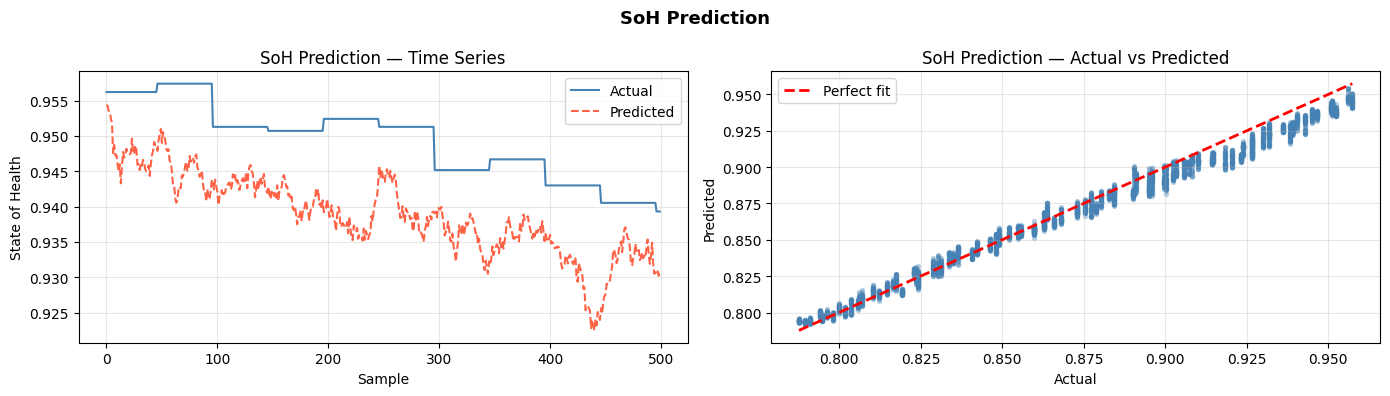

  [Plot saved → SoH_Prediction.png]

════════════════════════════════════════════════════════════
  STEP 4 — RUL Prediction (Transformer–LSTM)
════════════════════════════════════════════════════════════


Model: "RUL_Transformer_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ rul_input           │ (None, 20, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_projection    │ (None, 20, 64)    │        512 │ rul_input[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 64)    │     16,640 │ input_projection… │
│ (MultiHeadAttentio… │                   │            │ input_projection… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 20, 64)    │          0 │ input_projection… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 20, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 20, 128)   │          0 │ dense_25[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 20, 64)    │      8,256 │ dropout_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 20, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_26[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 20, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_11[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 20, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 20, 128)   │          0 │ dense_27[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 20, 64)    │      8,256 │ dropout_22[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 20, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_28[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_12[0][0]      │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 221,953 (867.00 KB)

 Trainable params: 221,953 (867.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 47s 129ms/step - loss: 0.0067 - mae: 0.0475 - val_loss: 0.0092 - val_mae: 0.0678 - learning_rate: 0.0010
Epoch 2/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 40s 125ms/step - loss: 0.0014 - mae: 0.0263 - val_loss: 0.0048 - val_mae: 0.0464 - learning_rate: 0.0010
Epoch 3/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 34s 126ms/step - loss: 0.0011 - mae: 0.0236 - val_loss: 0.0080 - val_mae: 0.0687 - learning_rate: 0.0010
Epoch 4/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 41s 126ms/step - loss: 8.5230e-04 - mae: 0.0207 - val_loss: 0.0062 - val_mae: 0.0611 - learning_rate: 0.0010
Epoch 5/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 41s 127ms/step - loss: 7.0026e-04 - mae: 0.0187 - val_loss: 0.0072 - val_mae: 0.0668 - learning_rate: 0.0010
Epoch 6/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 41s 125ms/step - loss: 6.3771e-04 - mae: 0.0177 - val_loss: 0.0055 - val_mae: 0.0594 - learning_rate: 0.0010
Epoch 7/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 40s 120ms/step - loss: 5.5555e-04 - mae: 0.0164 - val_loss: 0.0056 - val_mae: 

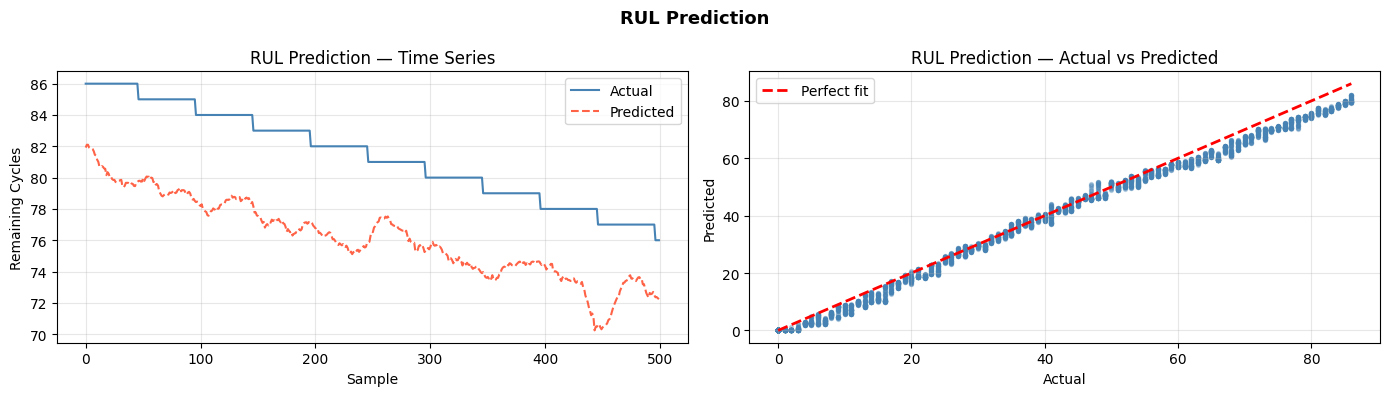

  [Plot saved → RUL_Prediction.png]

════════════════════════════════════════════════════════════
  STEP 5 — EV Range Prediction (DNN + GBM Ensemble)
════════════════════════════════════════════════════════════


Model: "EV_Range_DNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ range_input         │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 128)       │      1,024 │ range_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_31[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 64)        │      8,256 │ dropout_25[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_33[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 64)        │      4,160 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 64)        │      8,256 │ dropout_25[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 64)        │          0 │ dense_34[0][0],   │
│                     │                   │            │ dense_32[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 64)        │          0 │ add_13[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 32)        │      2,080 │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_36[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 32)        │      1,056 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 32)        │      2,080 │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 32)        │          0 │ dense_37[0][0],   │
│                     │                   │            │ dense_35[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ range_output        │ (None, 1)         │         33 │ add_14[0][0]      │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,841 (108.75 KB)

 Trainable params: 27,393 (107.00 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.2312 - mae: 0.3895 - val_loss: 0.0258 - val_mae: 0.1184 - learning_rate: 0.0010
Epoch 2/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0482 - mae: 0.1726 - val_loss: 0.0454 - val_mae: 0.1854 - learning_rate: 0.0010
Epoch 3/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0175 - mae: 0.1046 - val_loss: 0.0233 - val_mae: 0.1234 - learning_rate: 0.0010
Epoch 4/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0128 - mae: 0.0897 - val_loss: 0.0067 - val_mae: 0.0650 - learning_rate: 0.0010
Epoch 5/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0095 - mae: 0.0766 - val_loss: 0.0032 - val_mae: 0.0442 - learning_rate: 0.0010
Epoch 6/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0076 - mae: 0.0683 - val_loss: 0.0031 - val_mae: 0.0424 - learning_rate: 0.0010
Epoch 7/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0068 - mae: 0.0651 - val_loss: 0.0022 - val_mae: 0.0342 - learning_rate: 0.0010
Epoch 

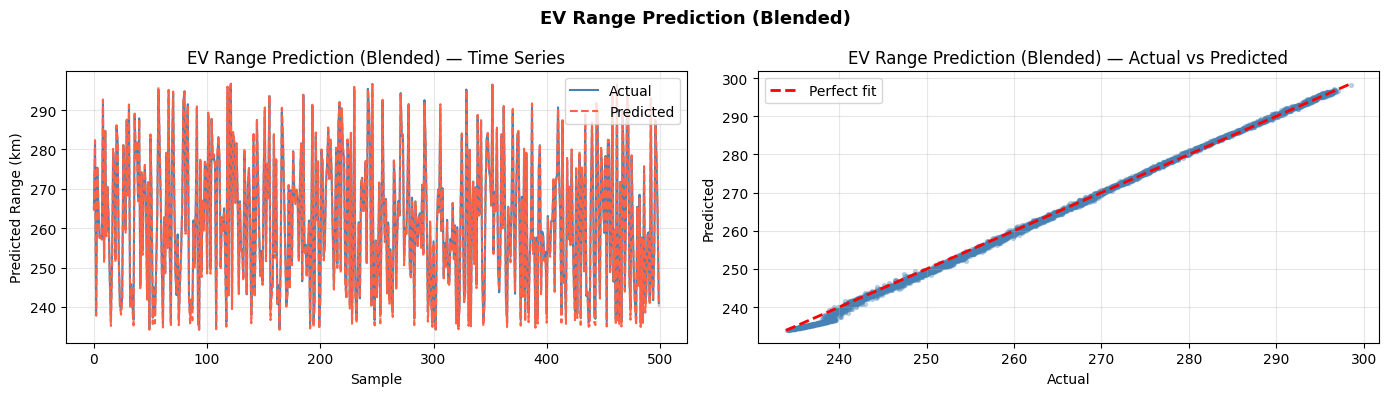

  [Plot saved → EV_Range_Prediction_Blended.png]


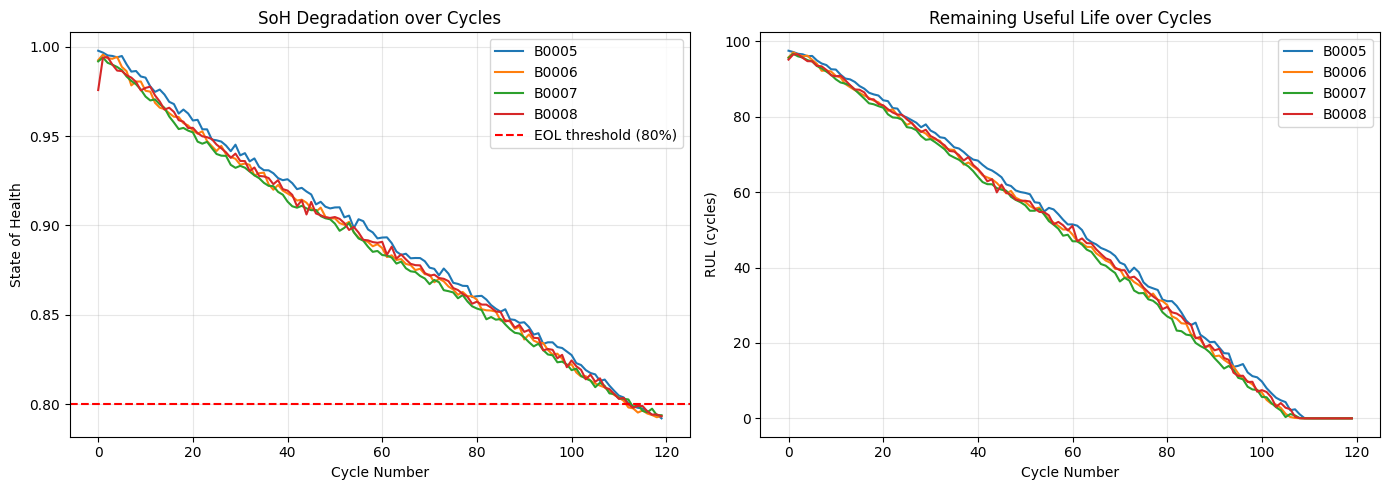

  [Plot saved → degradation_overview.png]

════════════════════════════════════════════════════════════
  PIPELINE SUMMARY — Evaluation Metrics
════════════════════════════════════════════════════════════
Module                              MAE       RMSE         R²
────────────────────────────────────────────────────────────
  SoC Estimation               0.002838   0.003549  -0.052809
  SoH Prediction               0.005838   0.007458   0.977587
  RUL Prediction               2.290898   2.960693   0.987949
  EV Range Prediction          0.602652   0.786028   0.997944
════════════════════════════════════════════════════════════

[*] Single-point range inference example:
   Predicted driving range: 253.5 km


In [41]:
#─────────────────────────────────────────────────────────────────────────────
# 12. ENTRY POINT
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    # ── Option A: Load from .mat files ────────────────────────────────────────
    # mat_files = {
    #     "B0005": "path/to/B0005.mat",
    #     "B0006": "path/to/B0006.mat",
    #     "B0007": "path/to/B0007.mat",
    #     "B0018": "path/to/B0018.mat",
    # }
    # raw_df   = load_nasa_battery_data(mat_files)
    # # ... run anomaly detection (Isolation Forest) to get clean_df ...

    # ── Option B: Assume clean_df already exists (your pipeline integration) ──
    # Replace the block below with your actual clean_df when integrating.
    print("[Demo] Generating synthetic NASA-like clean_df for smoke test ...")
    n_batteries = 4
    n_cycles    = 120
    n_per_cycle = 50
    rng = np.random.default_rng(SEED)
    rows = []
    for b in range(n_batteries):
        bid = f"B000{5+b}"
        init_cap = 1.8 + rng.uniform(-0.05, 0.05)
        for c in range(n_cycles):
            deg = max(0.0, 1.0 - c * 0.0018 + rng.normal(0, 0.002))
            cap = init_cap * deg
            for _ in range(n_per_cycle):
                rows.append({
                    "battery_id":          bid,
                    "cycle_number":        c,
                    "Voltage_measured":    3.6 + rng.uniform(-0.3, 0.3),
                    "Current_measured":    -1.5 + rng.uniform(-0.1, 0.1),
                    "Temperature_measured": 25  + rng.uniform(-3, 3),
                    "Capacity":            cap  + rng.normal(0, 0.005),
                })
    clean_df = pd.DataFrame(rows)

    # ── Run the pipeline ──────────────────────────────────────────────────────

    clean_df["temp_diff"] = clean_df["Temperature_measured"].diff()
    clean_df["voltage_diff"] = clean_df["Voltage_measured"].diff()
    clean_df["voltage_x_current"] = clean_df["Voltage_measured"] * clean_df["Current_measured"]
    clean_df["power"] = clean_df["voltage_x_current"]

    clean_df = clean_df.dropna()


    results, clean_df = run_full_pipeline(clean_df, seq_len=20, epochs=30)

    # ── Example single-point inference ───────────────────────────────────────
    print("\n[*] Single-point range inference example:")
    range_km = predict_range_single(
        soc=0.85, soh=0.92, temperature=26.0,
        voltage=3.7, current=-1.5, rul=45.0,
        range_results=results["range"],
        feature_cols=["Voltage_measured", "Current_measured",
                      "Temperature_measured", "power",
                      "SoC_predicted", "SoH_predicted", "RUL_predicted"],
    )
    print(f"   Predicted driving range: {range_km:.1f} km")



In [ ]:
# Run this once before you close:
clean_df.to_pickle('cleaned_battery_data.pkl')
